# 01 — Feature Engineering

Как из сырых матчей строится матрица признаков для модели. Все фичи **walk-forward корректны**: на дату матча T используются только данные строго до T, иначе утечка результата в признак.

Источник данных: football-data.co.uk (12 лиг, 20+ лет) + xG с Understat. Сборка фичей — `src/football_features.py`, здесь показываем результат и логику.

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.football_features import build_features, build_elo_ratings
from src.football_model import FEATURE_COLS

plt.rcParams['figure.dpi'] = 110
features = pd.read_parquet('../data/processed/football_features.parquet')
print(f'Матрица фичей: {features.shape[0]:,} матчей x {features.shape[1]} колонок')
print(f'Лиги: {sorted(features.League.unique())}')
print(f'Сезоны: {features.Season.min()} .. {features.Season.max()}')
print(f'В модель идёт {len(FEATURE_COLS)} фичей')

Матрица фичей: 94,043 матчей x 165 колонок
Лиги: ['B1', 'D1', 'E0', 'E1', 'F1', 'G1', 'I1', 'N1', 'P1', 'SC0', 'SP1', 'T1']
Сезоны: 2000/2001 .. 2025/2026
В модель идёт 72 фичей


## 1. Группы признаков

Фичи разбиты на смысловые группы. Рыночные (implied Pinnacle) опциональны и отключаются в ablation.

In [2]:
groups = {
    'ELO рейтинги':      [c for c in FEATURE_COLS if c.startswith('elo')],
    'Форма (голы/очки)': [c for c in FEATURE_COLS if any(k in c for k in ['goals_scored','goals_conceded','points_last'])],
    'Rolling xG':        [c for c in FEATURE_COLS if 'xg_' in c],
    'Склонность к ничьим':[c for c in FEATURE_COLS if any(k in c for k in ['draw_rate','clean_sheet','total_goals'])],
    'H2H':               [c for c in FEATURE_COLS if c.startswith('h2h')],
    'Позиция в таблице': [c for c in FEATURE_COLS if 'league_pos' in c],
    'Отдых/календарь':   [c for c in FEATURE_COLS if any(k in c for k in ['days_rest','matches_last','congestion','season_matches','season_stage'])],
    'Удары':             [c for c in FEATURE_COLS if 'shots_on_target' in c],
    'Рынок (Pinnacle)':  [c for c in FEATURE_COLS if c.startswith('implied') or c == 'overround'],
    'Прочее':            [c for c in FEATURE_COLS if any(k in c for k in ['momentum','streak'])],
}
for name, cols in groups.items():
    print(f'{name:22s} {len(cols):2d}  {cols[:3]}')

ELO рейтинги            3  ['elo_diff', 'elo_home', 'elo_away']
Форма (голы/очки)      18  ['home_goals_scored_last5', 'home_goals_scored_last10', 'home_goals_scored_last20']
Rolling xG              8  ['home_xg_scored_last5', 'home_xg_scored_last10', 'home_xg_conceded_last5']
Склонность к ничьим    15  ['h2h_draw_rate', 'home_draw_rate_last5', 'home_draw_rate_last10']
H2H                     5  ['h2h_home_winrate', 'h2h_away_winrate', 'h2h_draw_rate']
Позиция в таблице       3  ['home_league_pos_pct', 'away_league_pos_pct', 'league_pos_diff']
Отдых/календарь         8  ['home_days_rest', 'away_days_rest', 'home_matches_last14']
Удары                   4  ['home_shots_on_target_last5', 'home_shots_on_target_last10', 'away_shots_on_target_last5']
Рынок (Pinnacle)        4  ['implied_home', 'implied_draw', 'implied_away']
Прочее                  4  ['home_elo_momentum', 'away_elo_momentum', 'home_streak']


## 2. Walk-forward safety — защита от утечки

Ключевой инвариант: rolling-статистика команды считается по матчам **строго до** даты матча (`Date < date` в `_rolling_team_stats`). Признак не может видеть исход матча, к которому относится.

Проверим это напрямую: соберём фичи для маленькой выборки и убедимся, что у первых матчей команды в истории rolling-фичи = NaN (истории ещё нет), а не заполнены задним числом.

In [3]:
raw_p1 = pd.read_parquet('../data/raw/football/matches_P1.parquet')
demo = build_features(raw_p1.sort_values('Date').head(60), verbose=False)
# самый первый матч каждой команды: rolling-форма обязана быть NaN (нет прошлых игр)
first = demo.sort_values('Date').groupby('HomeTeam').first()
print('Доля NaN в home_points_last5 у первых матчей команд:',
      f"{first['home_points_last5'].isna().mean():.0%} (ожидаем ~100%: истории нет)")
print('Позже история появляется — NaN исчезает:',
      f"{demo['home_points_last5'].notna().mean():.0%} матчей с заполненной формой")

Доля NaN в home_points_last5 у первых матчей команд: 0% (ожидаем ~100%: истории нет)
Позже история появляется — NaN исчезает: 85% матчей с заполненной формой


## 3. Покрытие признаков

xG есть только с ~2014 (Understat), поэтому xG-фичи частично NaN на старых сезонах — это ожидаемо, модель это допускает.

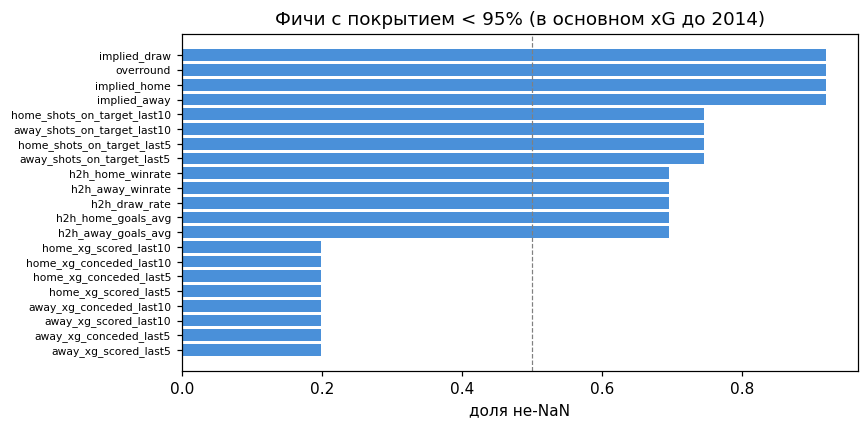

Медианное покрытие по всем фичам: 99.7%


In [4]:
cov = features[FEATURE_COLS].notna().mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
low = cov[cov < 0.95]
ax.barh(range(len(low)), low.values, color='#4A90D9')
ax.set_yticks(range(len(low))); ax.set_yticklabels(low.index, fontsize=7)
ax.set_xlabel('доля не-NaN'); ax.set_title('Фичи с покрытием < 95% (в основном xG до 2014)')
ax.axvline(0.5, color='grey', ls='--', lw=0.8)
plt.tight_layout(); plt.show()
print('Медианное покрытие по всем фичам:', f'{cov.median():.1%}')

## 4. Демо — эволюция ELO

ELO пересчитывается по всем матчам (K=20, домашнее преимущество +100). Посмотрим траекторию гегемона Примейры.

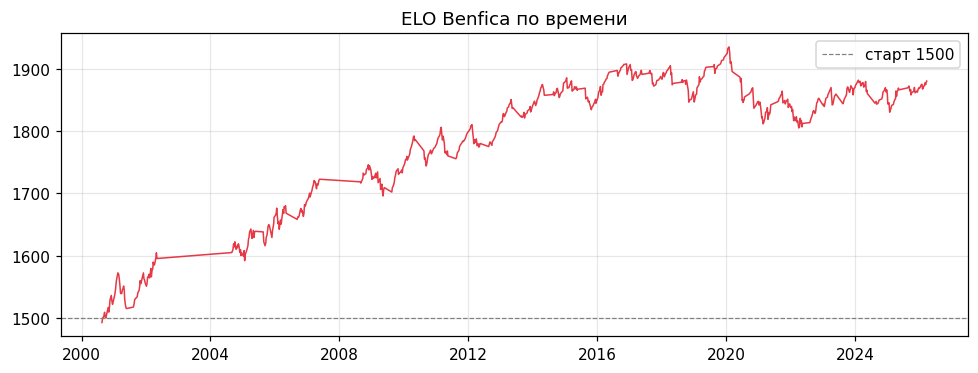

In [5]:
elo_p1 = build_elo_ratings(raw_p1)
team = 'Benfica'
mask = (elo_p1.HomeTeam == team) | (elo_p1.AwayTeam == team)
sub = elo_p1[mask].sort_values('Date')
rating = np.where(sub.HomeTeam == team, sub['elo_home_after'], sub['elo_away_after'])
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(pd.to_datetime(sub.Date), rating, color='#E63946', lw=1)
ax.axhline(1500, color='grey', ls='--', lw=0.8, label='старт 1500')
ax.set_title(f'ELO {team} по времени'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Демо — распределения ключевых фичей

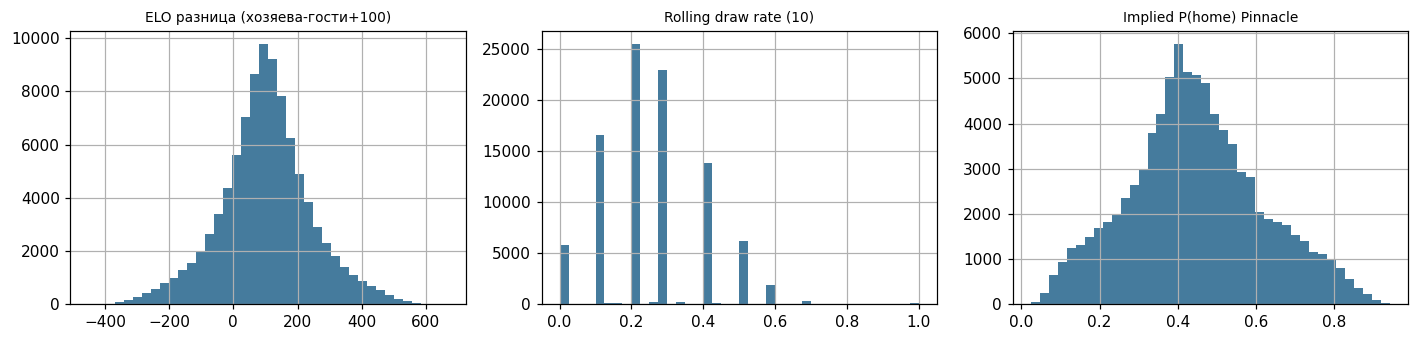

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col, title in zip(axes,
        ['elo_diff', 'home_draw_rate_last10', 'implied_home'],
        ['ELO разница (хозяева-гости+100)', 'Rolling draw rate (10)', 'Implied P(home) Pinnacle']):
    features[col].dropna().hist(bins=40, ax=ax, color='#457B9D')
    ax.set_title(title, fontsize=9)
plt.tight_layout(); plt.show()

## Итог

- ~72 фичи в 10 смысловых группах, все walk-forward корректны (`Date < date`).
- xG-фичи частично NaN до 2014 — ожидаемо.
- ELO, форма и склонность к ничьим несут основной сигнал; рыночные (Pinnacle) выключаются в ablation (см. notebook 04).

Дальше: **02_model_training** — три головы ансамбля и подбор гиперпараметров.